# Perfect Model Site-Level Calibration Tutorial

This tutorial demonstrates how to perform a perfect model calibration
experiment using ClimaLand. In a perfect model experiment, we generate
synthetic observations from our model with known parameters, then use ensemble
Kalman inversion to recover those parameters. This approach allows us to
evaluate the calibration method without the influence of model structural
errors.

In this tutorial we will calibrate the Vcmax25 parameter using synthetic latent heat
flux observations from the FLUXNET site (US-MOz).

## Overview

The tutorial covers:
1. Setting up a land surface model for a FLUXNET site (US-MOz)
2. Creating a synthetic observation dataset
3. Implementing Ensemble Kalman Inversion
4. Analyzing the calibration results

If you are unable to run this notebook, the same calibration experiment can be found in the [ClimaLand documentation](https://clima.github.io/ClimaLand.jl/stable/generated/calibration/perfect_model_site_level_calibration/).

## Prerequisites

First, ensure you have the required packages installed:

In [ ]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"]=0
using Pkg
default_jupyter_noteboks_pkgs = ["Adapt", "CSV", "DataFrames", "IJulia", "Lux",
  "Makie", "Plots", "Reactant", "CUDA_Runtime_jll", "CUDA"]
Pkg.rm(default_jupyter_noteboks_pkgs)
required_pkgs = ["ClimaLand", "ClimaDiagnostics", "CairoMakie",
  "EnsembleKalmanProcesses", "Random", "Logging", "ClimaAnalysis", "GeoMakie",
  "Printf", "StatsBase"]
Pkg.add(required_pkgs)
Pkg.instantiate()
Pkg.add(PackageSpec("ClimaLand", v"0.18.1"))
Pkg.precompile()

    Updating `~/.julia/environments/v1.11/Project.toml`
  [79e6a3ab] - Adapt v4.3.0
  [336ed68f] - CSV v0.10.15
  [a93c6f00] - DataFrames v1.7.0
  [7073ff75] - IJulia v1.29.2
  [b2108857] - Lux v1.17.0
  [ee78f7c6] - Makie v0.24.5
  [91a5bcdd] - Plots v1.40.18
  [3c362404] - Reactant v0.2.153
  [76a88914] - CUDA_Runtime_jll v0.19.0+0
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [47edcb42] - ADTypes v1.17.0
  [1520ce14] - AbstractTrees v0.4.5
  [35492f91] - AdaptivePredicates v1.2.0
  [66dad0bd] - AliasTables v1.1.3
  [27a7e980] - Animations v0.4.2
  [dce04be8] - ArgCheck v2.5.0
  [4fba245c] - ArrayInterface v7.19.0
  [67c07d97] - Automa v1.1.0
  [13072b0f] - AxisAlgorithms v1.1.0
  [39de3d68] - AxisArrays v0.4.7
  [18cc8868] - BaseDirs v1.3.2
  [d1d4a3ce] - BitFlags v0.1.9
  [62783981] - BitTwiddlingConvenienceFunctions v0.1.6
  [2a0fbf3d] - CPUSummary v0.2.7
  [96374032] - CRlibm v1.0.2
  [336ed68f] - CSV v0.10.15
  [d360d2e6] - ChainRulesCore v1.26.0
  [fb6a15b2] - Clos

## Setup and Imports

Load all the necessary packages for land surface modeling, diagnostics,
plotting, and ensemble methods:

In [ ]:
using ClimaLand
using ClimaLand.Domains: Column
using ClimaLand.Canopy
using ClimaLand.Simulations
import ClimaLand.FluxnetSimulations as FluxnetSimulations
import ClimaLand.Parameters as LP
import ClimaLand.LandSimVis as LandSimVis
import ClimaDiagnostics
import EnsembleKalmanProcesses as EKP
import EnsembleKalmanProcesses.ParameterDistributions as PD
using CairoMakie
CairoMakie.activate!()
using Statistics
using Logging
import Random
using Dates
using ClimaAnalysis, GeoMakie, Printf, StatsBase

## Configuration and Site Setup

Configure the experiment parameters and set up the FLUXNET site (US-MOz) with
its specific location, time settings, and atmospheric conditions.

Set random seed for reproducibility and floating point precision

In [ ]:
rng_seed = 1234
rng = Random.MersenneTwister(rng_seed)
const FT = Float32

Float32

Initialize land parameters and site configuration.

In [ ]:
earth_param_set = LP.LandParameters(FT)
site_ID = "US-MOz"
site_ID_val = FluxnetSimulations.replace_hyphen(site_ID)

:US_MOz

Get site-specific information: location coordinates, time offset, and sensor
height.

In [ ]:
(; time_offset, lat, long) =
    FluxnetSimulations.get_location(FT, Val(site_ID_val))
(; atmos_h) = FluxnetSimulations.get_fluxtower_height(FT, Val(site_ID_val))

(atmos_h = 32.0f0,)

Get maximum simulation start and end dates.

In [ ]:
(start_date, stop_date) = FluxnetSimulations.get_data_dates(site_ID, time_offset)
stop_date = DateTime(2010, 4, 1, 6, 30)  # Set the stop date manually
Δt = 450.0  # seconds

450.0

## Domain and Forcing Setup

Create the computational domain and load the necessary forcing data for the
land surface model.

Create a column domain representing a 2-meter deep soil column with 10
vertical layers.

In [ ]:
zmin = FT(-2)  # 2m depth
zmax = FT(0)   # surface
domain = Column(; zlim = (zmin, zmax), nelements = 10, longlat = (long, lat));

Load prescribed atmospheric and radiative forcing from FLUXNET data

In [ ]:
forcing = FluxnetSimulations.prescribed_forcing_fluxnet(
    site_ID,
    lat,
    long,
    time_offset,
    atmos_h,
    start_date,
    earth_param_set,
    FT,
);

Get Leaf Area Index (LAI) data from MODIS satellite observations.

In [ ]:
modis_lai_ncdata_path = ClimaLand.Artifacts.modis_lai_multiyear_paths(;
    start_date,
    end_date = stop_date,
)
LAI = ClimaLand.prescribed_lai_modis(
    modis_lai_ncdata_path,
    domain.space.surface,
    start_date,
);

## Model Setup

Create an integrated land model that couples canopy, snow, soil, and soil CO2
components. This comprehensive model allows us to simulate the full land
surface system and its interactions.

In [ ]:
function model(Vcmax25)
    Vcmax25 = FT(Vcmax25)

    #md # Set up ground conditions and define which components to simulate prognostically
    ground = ClimaLand.PrognosticGroundConditions{FT}()
    prognostic_land_components = (:canopy, :snow, :soil, :soilco2)

    #md # Prepare canopy domain and forcing
    canopy_domain = ClimaLand.Domains.obtain_surface_domain(domain)
    canopy_forcing = (; forcing.atmos, forcing.radiation, ground);

    #md # Set up photosynthesis parameters using the Farquhar model
    photosyn_defaults = Canopy.clm_photosynthesis_parameters(
        canopy_domain.space.surface,
    )
    photosynthesis = Canopy.FarquharModel{FT}(
        canopy_domain;
        photosynthesis_parameters = (;
            is_c3 = photosyn_defaults.is_c3,
            Vcmax25,
        ),
    )

    conductance = Canopy.MedlynConductanceModel{FT}(canopy_domain; g1 = FT(141))

    #md # Create canopy model
    canopy = ClimaLand.Canopy.CanopyModel{FT}(
        canopy_domain,
        canopy_forcing,
        LAI,
        earth_param_set;
        photosynthesis,
        prognostic_land_components,
        conductance,
    )

    #md # Create integrated land model
    land_model =
        LandModel{FT}(forcing, LAI, earth_param_set, domain, Δt; canopy)

    #md # Set initial conditions from FLUXNET data
    set_ic! = FluxnetSimulations.make_set_fluxnet_initial_conditions(
        site_ID,
        start_date,
        time_offset,
        land_model,
    )

    #md # Configure diagnostics to output sensible and latent heat fluxes hourly
    output_vars = ["shf", "lhf"]
    diagnostics = ClimaLand.default_diagnostics(
        land_model,
        start_date;
        output_writer = ClimaDiagnostics.Writers.DictWriter(),
        output_vars,
        average_period = :hourly,
    )

    #md # Create and run the simulation
    simulation = Simulations.LandSimulation(
        start_date,
        stop_date,
        Δt,
        land_model;
        set_ic!,
        user_callbacks = (),
        diagnostics,
    )
    solve!(simulation)
    return simulation
end

model (generic function with 1 method)

## Observation and Helper Functions

Define the observation function `G` that maps from parameter space to
observation space, along with supporting functions for data processing:

This function runs the model and computes diurnal average of latent heat flux

In [ ]:
function G(Vcmax25)
    simulation = model(Vcmax25)
    lhf = get_lhf(simulation)
    observation =
        Float64.(
            get_diurnal_average(
                lhf,
                simulation.start_date,
                simulation.start_date + Day(20),
            )
        )
    return observation
end

G (generic function with 1 method)

Helper function: Extract latent heat flux from simulation diagnostics

In [ ]:
function get_lhf(simulation)
    return ClimaLand.Diagnostics.diagnostic_as_vectors(
        simulation.diagnostics[1].output_writer,
        "lhf_1h_average",
    )
end

get_lhf (generic function with 1 method)

Helper function: Compute diurnal average of a variable

In [ ]:
function get_diurnal_average(var, start_date, spinup_date)
    (times, data) = var
    model_dates = if times isa Vector{DateTime}
        times
    else
        Second.(getproperty.(times, :counter)) .+ start_date
    end
    spinup_idx = findfirst(spinup_date .<= model_dates)
    model_dates = model_dates[spinup_idx:end]
    data = data[spinup_idx:end]

    hour_of_day = Hour.(model_dates)
    mean_by_hour = [mean(data[hour_of_day .== Hour(i)]) for i in 0:23]
    return mean_by_hour
end

get_diurnal_average (generic function with 1 method)

## Perfect Model Experiment Setup

Since this is a perfect model experiment, we generate synthetic observations
from our target parameter value. This parameter will be recovered by the
calibration.

In [ ]:
true_Vcmax25 = 0.0001 # [mol m-2 s-1]
observations = G(true_Vcmax25)

24-element Vector{Float64}:
 57.2796745300293
 55.94993209838867
  9.004277229309082
  3.383150577545166
  2.014784574508667
 11.826689720153809
  4.795387268066406
  2.735445737838745
  7.910235404968262
  4.175307750701904
  2.69277286529541
  6.347200870513916
  3.8828799724578857
  2.7000973224639893
  3.4234280586242676
  2.3195228576660156
  1.5934044122695923
 18.666685104370117
 19.592182159423828
 20.923925399780273
 45.67917251586914
 46.701351165771484
 57.59540939331055
 55.83218765258789

Define observation error covariance for the ensemble Kalman process. A flat
covariance is used here for simplicity.

In [ ]:
noise_covariance = 0.05 * EKP.I

LinearAlgebra.UniformScaling{Float64}
0.05*I

## Prior Distribution and Calibration Configuration

Set up the prior distribution for the parameter and configure the ensemble
Kalman inversion:

Constrained Gaussian prior for Vcmax25 with bounds [0, 2e-3]

In [ ]:
prior = PD.constrained_gaussian("Vcmax25", 1e-3, 5e-4, 0, 2e-3)

ParameterDistribution with 1 entries: 
'Vcmax25' with EnsembleKalmanProcesses.ParameterDistributions.Constraint{EnsembleKalmanProcesses.ParameterDistributions.Bounded}[Bounds: (0, 0.002)] over distribution EnsembleKalmanProcesses.ParameterDistributions.Parameterized(Distributions.Normal{Float64}(μ=0.0, σ=1.0253151205244289)) 


Set the ensemble size and number of iterations

In [ ]:
ensemble_size = 10
N_iterations = 3

3

## Ensemble Kalman Inversion

Initialize and run the ensemble Kalman process:

Sample the initial parameter ensemble from the prior distribution

In [ ]:
initial_ensemble = EKP.construct_initial_ensemble(rng, prior, ensemble_size)

ensemble_kalman_process = EKP.EnsembleKalmanProcess(
    initial_ensemble,
    observations,
    noise_covariance,
    EKP.Inversion();
    scheduler = EKP.DataMisfitController(
        terminate_at = Inf,
        on_terminate = "continue",
    ),
    rng,
);

EnsembleKalmanProcesses.EnsembleKalmanProcess{Float64, Int64, EnsembleKalmanProcesses.Inversion{Float64, Nothing, Nothing}, EnsembleKalmanProcesses.DataMisfitController{Float64, String}, EnsembleKalmanProcesses.NesterovAccelerator{Float64}, Vector{EnsembleKalmanProcesses.UpdateGroup}, Nothing}(EnsembleKalmanProcesses.DataContainers.DataContainer{Float64}[EnsembleKalmanProcesses.DataContainers.DataContainer{Float64}([-0.8325050664413828 2.6271025325751536 … -1.4948703507073922 -0.8871392387754122])], EnsembleKalmanProcesses.ObservationSeries{Vector{EnsembleKalmanProcesses.Observation{Vector{Vector{Float64}}, Vector{LinearAlgebra.Diagonal{Float64, Vector{Float64}}}, Vector{LinearAlgebra.Diagonal{Float64, Vector{Float64}}}, Vector{String}, Vector{UnitRange{Int64}}, Nothing}}, EnsembleKalmanProcesses.FixedMinibatcher{Vector{Vector{Int64}}, String, Random.TaskLocalRNG}, Vector{String}, Vector{Vector{Vector{Int64}}}, Nothing}(EnsembleKalmanProcesses.Observation{Vector{Vector{Float64}}, Vecto

Run the ensemble of forward models to iteratively update the parameter ensemble.
The logging code prevents unwanted warnings from cluttering the output.

This snippet will take a while to execute, since it is executing 30 forward model runs in sequence.

In [ ]:
Logging.with_logger(SimpleLogger(devnull, Logging.Error)) do
    for i in 1:N_iterations
        println("Iteration $i")
        params_i = EKP.get_ϕ_final(prior, ensemble_kalman_process)
        G_ens = hcat([G(params_i[:, j]...) for j in 1:ensemble_size]...)
        EKP.update_ensemble!(ensemble_kalman_process, G_ens)
    end
end

Iteration 1
Iteration 2
Iteration 3


## Results Analysis and Visualization
Get the mean of the final parameter ensemble:

In [ ]:
EKP.get_ϕ_mean_final(prior, ensemble_kalman_process)

1-element Vector{Float64}:
 0.0005212983290301166

Now, let's analyze the calibration results by examining parameter evolution
and comparing model outputs across iterations.

Plot the parameter ensemble evolution over iterations to visualize
convergence:

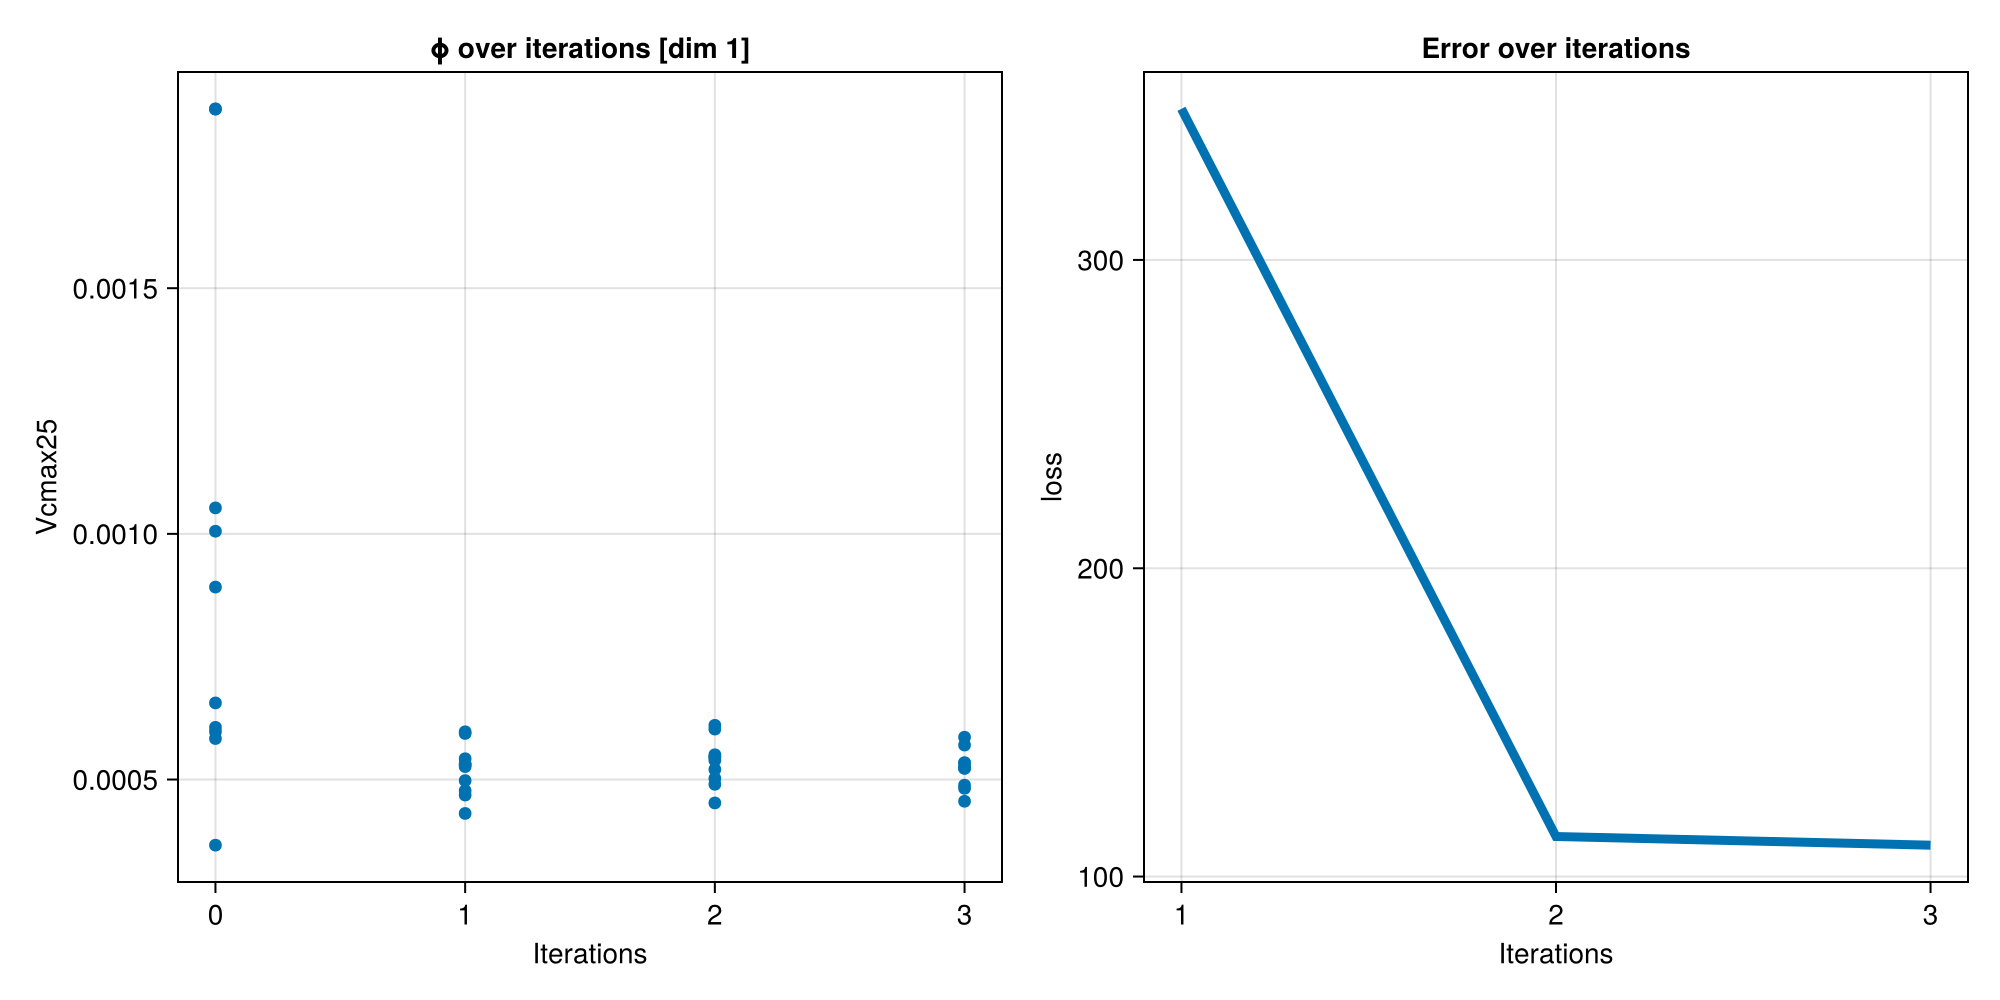

In [ ]:
dim_size = sum(length.(EKP.batch(prior)))
fig = CairoMakie.Figure(size = ((dim_size + 1) * 500, 500))

for i in 1:dim_size
    EKP.Visualize.plot_ϕ_over_iters(
        fig[1, i],
        ensemble_kalman_process,
        prior,
        i,
    )
end

EKP.Visualize.plot_error_over_iters(
    fig[1, dim_size + 1],
    ensemble_kalman_process,
)
CairoMakie.save("constrained_params_and_error.png", fig)
fig

Compare the model output between the first and last iterations to assess
improvement:

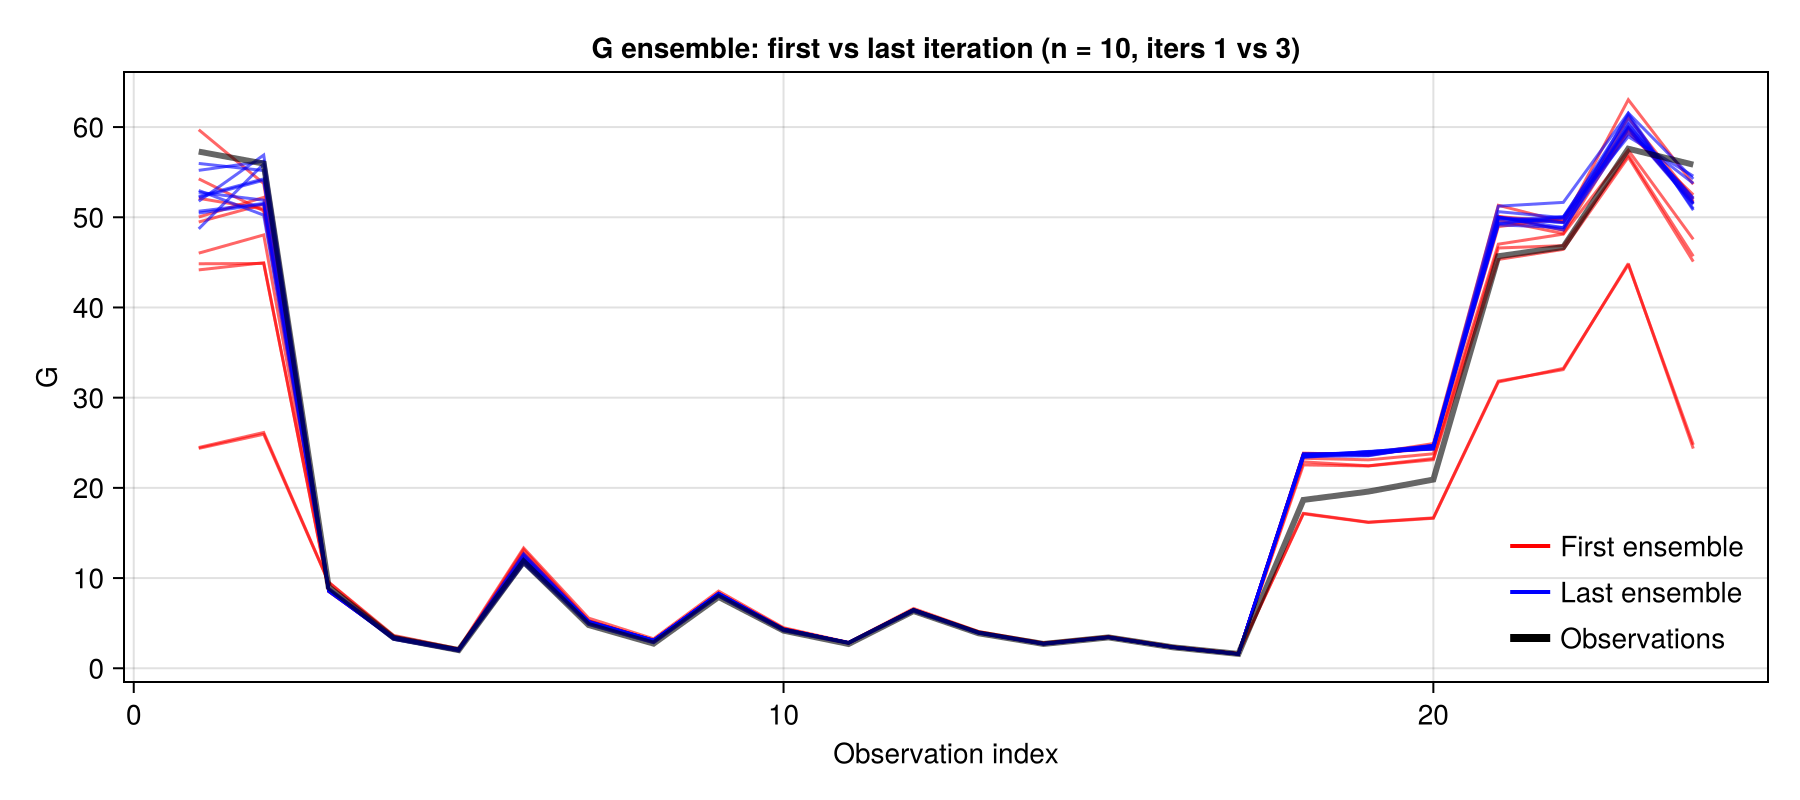

In [ ]:
fig = CairoMakie.Figure(size = (900, 400))

first_G_ensemble = EKP.get_g(ensemble_kalman_process, 1)
last_iter = EKP.get_N_iterations(ensemble_kalman_process)
last_G_ensemble = EKP.get_g(ensemble_kalman_process, last_iter)
n_ens = EKP.get_N_ens(ensemble_kalman_process)

ax = Axis(
    fig[1, 1];
    title = "G ensemble: first vs last iteration (n = $(n_ens), iters 1 vs $(last_iter))",
    xlabel = "Observation index",
    ylabel = "G",
)

# Plot model output of first vs last iteration ensemble
for g in eachcol(first_G_ensemble)
    lines!(ax, 1:length(g), g; color = (:red, 0.6), linewidth = 1.5)
end

for g in eachcol(last_G_ensemble)
    lines!(ax, 1:length(g), g; color = (:blue, 0.6), linewidth = 1.5)
end

lines!(ax, 1:length(observations), observations; color = (:black, 0.6), linewidth = 3)

axislegend(
    ax,
    [
        LineElement(color = :red, linewidth = 2),
        LineElement(color = :blue, linewidth = 2),
        LineElement(color = :black, linewidth = 4),

    ],
    ["First ensemble", "Last ensemble", "Observations"];
    position = :rb,
    framevisible = false,
)

CairoMakie.resize_to_layout!(fig)
CairoMakie.save("G_first_and_last.png", fig)
fig


---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*